In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# LightCurve

## Prepare data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd

from grb.analysis import Analyzer
from grb.io import read_data, filter_data
from grb.functions import *
from grb.prior import *

In [3]:
# Prepare data and summarize existing posterior results from fit_results.pkl
with open("fit_results.pkl", "rb") as f:
    fit_results = pickle.load(f)

# --- Summary table ---
summary_rows = []
for name, key, param_names in [
    ("XRT (PL)", "xrt", ["F0", "alpha"]),
    ("Ic (PL)", "Ic", ["F0", "alpha"]),
    ("Rc (PL)", "Rc", ["F0", "alpha"]),
    ("r/r' (BknPL)", "r", ["F_break", "t_break", "alpha_1", "alpha_2"]),
    ("i (PL+BknPL)", "i", ["F0", "alpha", "F_break", "t_break", "alpha_1", "alpha_2"]),
]:
    res = fit_results[key]["results"]
    means = res["posterior"]["mean"]
    stds = res["posterior"]["stdev"]
    for j, pname in enumerate(param_names):
        summary_rows.append({
            "Band": name,
            "Parameter": pname,
            "Mean": f"{means[j]:.4g}",
            "Std": f"{stds[j]:.4g}",
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print(f"\nExisting logZ values:")
for name, key in [("XRT", "xrt"), ("Ic", "Ic"), ("Rc", "Rc"), ("r/r'", "r"), ("i", "i")]:
    res = fit_results[key]["results"]
    print(f"  {name}: logZ = {res['logz']:.2f} +/- {res['logzerr']:.2f}")

# --- Prepare data ---
# i band data
df_i_exp = read_data("circular", add_converted_flux=True)
df_i_exp = filter_data(df_i_exp, filter_name="i", remove_upper_limits=True)
combined_func = lambda t, *params: power_law(t, *params[:2]) + broken_power_law(t, *params[2:])

# r/r' band data
df_r_exp = read_data("circular", add_converted_flux=True)
df_r_exp = filter_data(df_r_exp, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))

# Rc band data
df_Rc_exp = read_data("circular", add_converted_flux=True)
df_Rc_exp = filter_data(df_Rc_exp, filter_name=["Rc"], remove_upper_limits=True, facility_name="Leavitt")

# Ic band data
df_Ic_exp = read_data("circular", add_converted_flux=True)
df_Ic_exp = filter_data(df_Ic_exp, filter_name=["Ic"], remove_upper_limits=True, facility_name="Leavitt")

# XRT data
df_xrt_exp = read_data("xrt")
df_xrt_exp = filter_data(df_xrt_exp, exclude_time_range=(3e3, 1e4))
flx_err_xrt_exp = np.array([max(np.abs(h), np.abs(l))
                             for h, l in zip(df_xrt_exp["Flux_high"], df_xrt_exp["Flux_low"])])

# --- Extract posteriors ---
# -- XRT posteriors --
post_xrt_alpha_mean = fit_results["xrt"]["results"]["posterior"]["mean"][1]
post_xrt_alpha_std  = fit_results["xrt"]["results"]["posterior"]["stdev"][1]

# -- Ic posteriors --
post_Ic_alpha_mean = fit_results["Ic"]["results"]["posterior"]["mean"][1]
post_Ic_alpha_std  = fit_results["Ic"]["results"]["posterior"]["stdev"][1]

# -- Rc posteriors --
post_Rc_alpha_mean = fit_results["Rc"]["results"]["posterior"]["mean"][1]
post_Rc_alpha_std  = fit_results["Rc"]["results"]["posterior"]["stdev"][1]

# -- r/r' posteriors --
post_r_Fbreak_mean  = fit_results["r"]["results"]["posterior"]["mean"][0]
post_r_Fbreak_std   = fit_results["r"]["results"]["posterior"]["stdev"][0]
post_r_tbreak_mean  = fit_results["r"]["results"]["posterior"]["mean"][1]
post_r_tbreak_std   = fit_results["r"]["results"]["posterior"]["stdev"][1]
post_r_alpha1_mean  = fit_results["r"]["results"]["posterior"]["mean"][2]
post_r_alpha1_std   = fit_results["r"]["results"]["posterior"]["stdev"][2]
post_r_alpha2_mean  = fit_results["r"]["results"]["posterior"]["mean"][3]
post_r_alpha2_std   = fit_results["r"]["results"]["posterior"]["stdev"][3]

# -- i band posteriors (from PL+BknPL fit) --
post_i_alpha_mean    = fit_results["i"]["results"]["posterior"]["mean"][1]
post_i_alpha_std     = fit_results["i"]["results"]["posterior"]["stdev"][1]
post_i_tbreak_mean   = fit_results["i"]["results"]["posterior"]["mean"][3]
post_i_tbreak_std    = fit_results["i"]["results"]["posterior"]["stdev"][3]
post_i_alpha1_mean   = fit_results["i"]["results"]["posterior"]["mean"][4]
post_i_alpha1_std    = fit_results["i"]["results"]["posterior"]["stdev"][4]
post_i_alpha2_mean   = fit_results["i"]["results"]["posterior"]["mean"][5]
post_i_alpha2_std    = fit_results["i"]["results"]["posterior"]["stdev"][5]

# --- Weighted averages ---
# Inverse-variance weighted average of Ic and Rc alpha posteriors
w_Ic = 1.0 / post_Ic_alpha_std**2
w_Rc = 1.0 / post_Rc_alpha_std**2
combined_alpha_mean = (w_Ic * post_Ic_alpha_mean + w_Rc * post_Rc_alpha_mean) / (w_Ic + w_Rc)
combined_alpha_std  = 1.0 / np.sqrt(w_Ic + w_Rc)

# Inverse-variance weighted average of r/r' alpha_2 and XRT alpha (both post-break)
w_r_a2  = 1.0 / post_r_alpha2_std**2
w_xrt   = 1.0 / post_xrt_alpha_std**2
combined_post_break_alpha_mean = (w_r_a2 * post_r_alpha2_mean + w_xrt * post_xrt_alpha_mean) / (w_r_a2 + w_xrt)
combined_post_break_alpha_std  = 1.0 / np.sqrt(w_r_a2 + w_xrt)

# Inverse-variance weighted average of Rc + XRT alpha
w_Rc_x = 1.0 / post_Rc_alpha_std**2
w_xrt_x = 1.0 / post_xrt_alpha_std**2
combined_Rc_xrt_alpha_mean = (w_Rc_x * post_Rc_alpha_mean + w_xrt_x * post_xrt_alpha_mean) / (w_Rc_x + w_xrt_x)
combined_Rc_xrt_alpha_std  = 1.0 / np.sqrt(w_Rc_x + w_xrt_x)

# Inverse-variance weighted average of Ic + Rc + XRT alpha
w_all = [1.0/post_Ic_alpha_std**2, 1.0/post_Rc_alpha_std**2, 1.0/post_xrt_alpha_std**2]
m_all = [post_Ic_alpha_mean, post_Rc_alpha_mean, post_xrt_alpha_mean]
combined_all_alpha_mean = sum(w*m for w,m in zip(w_all, m_all)) / sum(w_all)
combined_all_alpha_std  = 1.0 / np.sqrt(sum(w_all))

print("\nCross-band alpha posteriors:")
print(f"  XRT alpha: {post_xrt_alpha_mean:.4f} +/- {post_xrt_alpha_std:.4f}")
print(f"  Ic alpha:  {post_Ic_alpha_mean:.4f} +/- {post_Ic_alpha_std:.4f}")
print(f"  Rc alpha:  {post_Rc_alpha_mean:.4f} +/- {post_Rc_alpha_std:.4f}")
print(f"  Ic+Rc weighted:  {combined_alpha_mean:.4f} +/- {combined_alpha_std:.4f}")
print(f"  r/r' alpha_1: {post_r_alpha1_mean:.4f} +/- {post_r_alpha1_std:.4f}")
print(f"  r/r' alpha_2: {post_r_alpha2_mean:.4f} +/- {post_r_alpha2_std:.4f}")
print(f"  r/r' t_break: {post_r_tbreak_mean:.4f} +/- {post_r_tbreak_std:.4f}")
print(f"  r/r' alpha_2 + XRT weighted (post-break): {combined_post_break_alpha_mean:.4f} +/- {combined_post_break_alpha_std:.4f}")
print(f"  i alpha (PL comp): {post_i_alpha_mean:.4f} +/- {post_i_alpha_std:.4f}")
print(f"  i alpha_1 (BknPL): {post_i_alpha1_mean:.4f} +/- {post_i_alpha1_std:.4f}")
print(f"  i alpha_2 (BknPL): {post_i_alpha2_mean:.4f} +/- {post_i_alpha2_std:.4f}")
print(f"  i t_break (BknPL): {post_i_tbreak_mean:.4f} +/- {post_i_tbreak_std:.4f}")
print(f"  Rc+XRT weighted alpha: {combined_Rc_xrt_alpha_mean:.4f} +/- {combined_Rc_xrt_alpha_std:.4f}")
print(f"  Ic+Rc+XRT weighted alpha: {combined_all_alpha_mean:.4f} +/- {combined_all_alpha_std:.4f}")

print(f"\nData sizes: Ic={len(df_Ic_exp)}, Rc={len(df_Rc_exp)}, r={len(df_r_exp)}, i={len(df_i_exp)}, xrt={len(df_xrt_exp)}")


,Band,Parameter,Mean,Std
0,XRT (PL),F0,1.52e-11,6.229e-13
1,XRT (PL),alpha,1.035,0.02464
2,Ic (PL),F0,3.771,0.1883
3,Ic (PL),alpha,1.163,0.03998
4,Rc (PL),F0,3.819,0.0268
5,Rc (PL),alpha,1.338,0.008354
6,r/r' (BknPL),F_break,0.5133,0.1135
7,r/r' (BknPL),t_break,4.847,0.4832
8,r/r' (BknPL),alpha_1,1.182,0.0141
9,r/r' (BknPL),alpha_2,2.146,0.1345



Existing logZ values:
  XRT: logZ = -30.50 +/- 0.26
  Ic: logZ = -89.38 +/- 0.19
  Rc: logZ = -362.71 +/- 0.45
  r/r': logZ = -43.93 +/- 0.51
  i: logZ = -88.53 +/- 0.24

Cross-band alpha posteriors:
  XRT alpha: 1.0348 +/- 0.0246
  Ic alpha:  1.1632 +/- 0.0400
  Rc alpha:  1.3379 +/- 0.0084
  Ic+Rc weighted:  1.3306 +/- 0.0082
  r/r' alpha_1: 1.1824 +/- 0.0141
  r/r' alpha_2: 2.1456 +/- 0.1345
  r/r' t_break: 4.8470 +/- 0.4832
  r/r' alpha_2 + XRT weighted (post-break): 1.0709 +/- 0.0242
  i alpha (PL comp): 3.2651 +/- 0.4096
  i alpha_1 (BknPL): 0.1831 +/- 0.0116
  i alpha_2 (BknPL): 1.6176 +/- 0.0193
  i t_break (BknPL): 2.1082 +/- 0.0247
  Rc+XRT weighted alpha: 1.3066 +/- 0.0079
  Ic+Rc+XRT weighted alpha: 1.3012 +/- 0.0078

Data sizes: Ic=18, Rc=35, r=10, i=14, xrt=30


## Ic band fit

In [4]:
# Exp 5d: Ic PL, alpha prior from r/r' alpha_1 (pre-break)
pb, pr = power_law_prior()
pb["alpha"] = (post_r_alpha1_mean, post_r_alpha1_std)
pr["alpha"] = "norm"

alz_Ic_5d = Analyzer(df_Ic_exp["Time"], df_Ic_exp["flux_mJy"], power_law,
                      param_bounds=pb, prior=pr, y_data_error=df_Ic_exp["flux_error_mJy"])
alz_Ic_5d.run()
print(f"Exp 5d best-fit: {alz_Ic_5d.best_fit_params}")
print(f"Exp 5d logZ = {alz_Ic_5d.results['logz']:.2f} +/- {alz_Ic_5d.results['logzerr']:.2f}")
print(f"Original Ic logZ = {fit_results['Ic']['results']['logz']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-8e+01   [-77.5317..-77.5317]*| it/evals=3790/49746 eff=7.6487% N=292        2   
[ultranest] Likelihood function evaluations: 49746
[ultranest]   logZ = -85.92 +- 0.1076
[ultranest] Effective samples strategy satisfied (ESS = 964.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.12 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.11 tail:0.01 total:0.11 required:<0.50
[ultranest] done iterating.
Exp 5d best-fit: [3.7577073771838556, 1.1611140998722966]
Exp 5d logZ = -85.90 +/- 0.20
Original Ic logZ = -89.38


In [5]:
# Exp 3i: Ic with broken PL, alpha_2 from XRT only
pb, pr = broken_power_law_prior()
pb["alpha_2"] = (post_xrt_alpha_mean, post_xrt_alpha_std)
pr["alpha_2"] = "norm"

alz_Ic_3i = Analyzer(df_Ic_exp["Time"], df_Ic_exp["flux_mJy"], broken_power_law,
                      param_bounds=pb, prior=pr, y_data_error=df_Ic_exp["flux_error_mJy"])
alz_Ic_3i.run()
print(f"Exp 3i best-fit: {alz_Ic_3i.best_fit_params}")
print(f"Exp 3i logZ = {alz_Ic_3i.results['logz']:.2f} +/- {alz_Ic_3i.results['logzerr']:.2f}")
print(f"Original Ic (PL) logZ = {fit_results['Ic']['results']['logz']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+01   [-77.5251..-77.5250]*| it/evals=5112/186140 eff=2.7481% N=295    5    300 
[ultranest] Likelihood function evaluations: 186206
[ultranest]   logZ = -89.7 +- 0.1565
[ultranest] Effective samples strategy satisfied (ESS = 1917.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.18 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.
Exp 3i best-fit: [1.057804777422704, 2.980784674247881, 0.2034734251325669, 1.1184945169436735]
Exp 3i logZ = -89.73 +/- 0.27
Original Ic (PL) logZ = -89.38


## Rc band fit

In [6]:
# Exp 3f: Rc with broken PL, alpha_2 from XRT only
pb, pr = broken_power_law_prior()
pb["alpha_2"] = (post_xrt_alpha_mean, post_xrt_alpha_std)
pr["alpha_2"] = "norm"

alz_Rc_3f = Analyzer(df_Rc_exp["Time"], df_Rc_exp["flux_mJy"], broken_power_law,
                      param_bounds=pb, prior=pr, y_data_error=df_Rc_exp["flux_error_mJy"])
alz_Rc_3f.run()
print(f"Exp 3f best-fit: {alz_Rc_3f.best_fit_params}")
print(f"Exp 3f logZ = {alz_Rc_3f.results['logz']:.2f} +/- {alz_Rc_3f.results['logzerr']:.2f}")
print(f"Original Rc (PL) logZ = {fit_results['Rc']['results']['logz']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+02  .20 [-190.2065..-190.2062]*| it/evals=16585/551349 eff=3.0084% N=293   3     
[ultranest] Likelihood function evaluations: 551349
[ultranest]   logZ = -242 +- 0.2481
[ultranest] Effective samples strategy satisfied (ESS = 3339.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 291 minimum live points (dlogz from 0.21 to 0.59, need <0.5)
[ultranest]   logZ error budget: single: 0.40 bs:0.25 tail:0.01 total:0.25 required:<0.50
[ultranest] done iterating.
Exp 3f best-fit: [1.6869919645148117, 1.7800087960888908, 2.9271155518109033, 1.2371048819919894]
Exp 3f logZ = -241.89 +/- 0.33
Original Rc (PL) logZ = -362.71


## r/ r' bands fit

In [7]:
# Exp 7e: r/r' PL, flat priors (baseline for power law model)
alz_r_7e = Analyzer(df_r_exp["Time"], df_r_exp["flux_mJy"], power_law,
                     y_data_error=df_r_exp["flux_error_mJy"])
alz_r_7e.run()
print(f"Exp 7e best-fit: {alz_r_7e.best_fit_params}")
print(f"Exp 7e logZ = {alz_r_7e.results['logz']:.2f} +/- {alz_r_7e.results['logzerr']:.2f}")
print(f"Original r (BknPL, flat) logZ = {fit_results['r']['results']['logz']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-3e+02  .17 [-296.1821..-296.1821]*| it/evals=5400/106078 eff=5.0956% N=290      0  
[ultranest] Likelihood function evaluations: 106130
[ultranest]   logZ = -310.2 +- 0.2001
[ultranest] Effective samples strategy satisfied (ESS = 1139.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
Exp 7e best-fit: [3.594470711892716, 1.422767547644149]
Exp 7e logZ = -310.20 +/- 0.45
Original r (BknPL, flat) logZ = -43.93


In [8]:
# Exp 2a: r/r', alpha_1 prior from Ic
pb, pr = broken_power_law_prior()
pb["alpha_1"] = (post_Ic_alpha_mean, post_Ic_alpha_std)
pr["alpha_1"] = "norm"

alz_r_2a = Analyzer(df_r_exp["Time"], df_r_exp["flux_mJy"], broken_power_law,
                     param_bounds=pb, prior=pr, y_data_error=df_r_exp["flux_error_mJy"])
alz_r_2a.run()
print(f"Exp 2a best-fit: {alz_r_2a.best_fit_params}")
print(f"Exp 2a logZ = {alz_r_2a.results['logz']:.2f} +/- {alz_r_2a.results['logzerr']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+01   [-22.1532..-22.1531]*| it/evals=6720/208620 eff=3.2229% N=294         4   
[ultranest] Likelihood function evaluations: 208620
[ultranest]   logZ = -40.39 +- 0.1947
[ultranest] Effective samples strategy satisfied (ESS = 1685.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.
Exp 2a best-fit: [0.4850933762177786, 4.982562478703081, 1.1835126711199093, 2.1797887745079505]
Exp 2a logZ = -40.35 +/- 0.31


## i band fit

In [9]:
# Exp 1i: i band, flat baseline (no informative priors)
# Baseline: what happens without ANY cross-band information?
pb, pr = power_law_prior()
pb_bk, pr_bk = broken_power_law_prior()
pb.update(pb_bk)
pr.update(pr_bk)
# No Gaussian priors — all flat/uninformative

alz_i_1i = Analyzer(df_i_exp["Time"], df_i_exp["flux_mJy"], combined_func,
                     param_bounds=pb, prior=pr, y_data_error=df_i_exp["flux_error_mJy"])
alz_i_1i.run()
print(f"Exp 1i best-fit: {alz_i_1i.best_fit_params}")
print(f"Exp 1i logZ = {alz_i_1i.results['logz']:.2f} +/- {alz_i_1i.results['logzerr']:.2f}")


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-6e+01   [-57.9158..-57.9155]*| it/evals=10548/453150 eff=2.3292% N=300            0 
[ultranest] Likelihood function evaluations: 453267
[ultranest]   logZ = -88.39 +- 0.2242
[ultranest] Effective samples strategy satisfied (ESS = 1971.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
Exp 1i best-fit: [7.2287671979485e-05, 3.194515652911671, 1.8512130808477016, 2.1118161253429104, 0.18153709563857917, 1.6209772534044213]
Exp 1i logZ = -88.36 +/- 0.44


## g band fit

In [21]:
# g-band Broken Power Law fit
df_g_exp = read_data("circular", add_converted_flux=True)
df_g_exp = filter_data(df_g_exp, filter_name=["g"], remove_upper_limits=True)
print(f"g-band: {len(df_g_exp)} data points, Time: {df_g_exp['Time'].min():.2f}-{df_g_exp['Time'].max():.2f} h")

pb, pr = broken_power_law_prior()
alz_g_bknpl = Analyzer(df_g_exp["Time"], df_g_exp["flux_mJy"], broken_power_law,
                        param_bounds=pb, prior=pr, y_data_error=df_g_exp["flux_error_mJy"])
alz_g_bknpl.run()

print(f"\ng BknPL: best_fit={[f'{p:.4g}' for p in alz_g_bknpl.best_fit_params]}")
means = alz_g_bknpl.results["posterior"]["mean"]
stds = alz_g_bknpl.results["posterior"]["stdev"]
for i, pname in enumerate(alz_g_bknpl.params):
    print(f"  {pname} = {means[i]:.4f} +/- {stds[i]:.4f}")
print(f"  logZ = {alz_g_bknpl.results['logz']:.2f} +/- {alz_g_bknpl.results['logzerr']:.2f}")
print(f"\nOriginal g PL logZ = {fit_results['g']['results']['logz']:.2f}")

g-band: 6 data points, Time: 2.10-52.08 h
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-0.7   [-0.8686..-0.8685]*| it/evals=7500/267834 eff=2.7981% N=286        6       
[ultranest] Likelihood function evaluations: 267905
[ultranest]   logZ = -22.49 +- 0.2006
[ultranest] Effective samples strategy satisfied (ESS = 1513.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

g BknPL: best_fit=['0.4482', '4.343', '1.23', '1.952']
  F_bpl = 0.4467 +/- 0.0378
  t_break = 4.3579 +/- 0.2090
  alpha_1 = 1.2342 +/- 0.0436
  alpha_2 = 1.9514 +/- 0.0173
  logZ = -22.44 +/- 0.36

Original g PL logZ = -43.21


## Clear Band

In [ ]:
# Clear band fitting - separate per facility (different zero points/systematics)
# Facilities: Calapai, BassanoBrescianoObservatory, ISON-Castelgrande
# Note: "clear" filter has no standard zero point, using AB mag -> pseudo-flux (mJy)

from grb.utils import _mag_to_flux_mJy

df_circ = read_data("circular")

# Filter clear band data (both "clear" and "Clear") from the 3 facilities
facilities = ["Calapai", "BassanoBrescianoObservatory", "ISON-Castelgrande"]
df_clear_all = df_circ[
    (df_circ["Filter"].str.lower() == "clear") &
    (df_circ["Facility"].isin(facilities)) &
    (~df_circ["Limit"])
].copy()

# Convert mag to pseudo-flux (AB zero point)
flx, flx_err = [], []
for _, row in df_clear_all.iterrows():
    f, fe = _mag_to_flux_mJy(row["Mag"], row["Error"])
    flx.append(f)
    flx_err.append(fe)
df_clear_all.loc[:, "flux_mJy"] = flx
df_clear_all.loc[:, "flux_error_mJy"] = flx_err

# --- Fit each facility separately ---
clear_results = {}

for fac in facilities:
    df_fac = df_clear_all[df_clear_all["Facility"] == fac]
    print(f"\n{'='*60}")
    print(f"Facility: {fac} ({len(df_fac)} data points, Time: {df_fac['Time'].min():.2f}-{df_fac['Time'].max():.2f} h)")

    alz = Analyzer(df_fac["Time"], df_fac["flux_mJy"], power_law,
                    y_data_error=df_fac["flux_error_mJy"])
    alz.run()

    clear_results[fac] = {
        "analyzer": alz,
        "best_fit_params": alz.best_fit_params,
        "params": alz.params,
        "x_data": list(alz.x_data),
        "y_data": list(alz.y_data),
        "y_data_error": list(alz.y_data_error) if alz.y_data_error is not None else None,
        "results": alz.results,
        "logz": alz.results["logz"],
        "logzerr": alz.results["logzerr"],
        "alpha_mean": alz.results["posterior"]["mean"][1],
        "alpha_std": alz.results["posterior"]["stdev"][1],
    }

    print(f"  best-fit: F0={alz.best_fit_params[0]:.4f}, alpha={alz.best_fit_params[1]:.4f}")
    print(f"  alpha = {clear_results[fac]['alpha_mean']:.4f} +/- {clear_results[fac]['alpha_std']:.4f}")
    print(f"  logZ = {alz.results['logz']:.2f} +/- {alz.results['logzerr']:.2f}")

# --- Summary comparison ---
print(f"\n{'='*60}")
print("Clear band alpha comparison:")
for fac in facilities:
    r = clear_results[fac]
    print(f"  {fac}: alpha = {r['alpha_mean']:.4f} +/- {r['alpha_std']:.4f}  (logZ = {r['logz']:.2f})")

In [16]:
# Clear band - Broken Power Law test (Calapai & BassanoBrescianoObservatory only)
# ISON-Castelgrande has too few points (7) for 4-parameter BknPL

clear_bknpl_results = {}
bknpl_facilities = ["Calapai", "BassanoBrescianoObservatory"]

for fac in bknpl_facilities:
    df_fac = df_clear_all[df_clear_all["Facility"] == fac]
    print(f"\n{'='*60}")
    print(f"BknPL - {fac} ({len(df_fac)} data points)")

    pb, pr = broken_power_law_prior()
    alz = Analyzer(df_fac["Time"], df_fac["flux_mJy"], broken_power_law,
                    param_bounds=pb, prior=pr, y_data_error=df_fac["flux_error_mJy"])
    alz.run()

    clear_bknpl_results[fac] = {
        "analyzer": alz,
        "best_fit_params": alz.best_fit_params,
        "params": alz.params,
        "x_data": list(alz.x_data),
        "y_data": list(alz.y_data),
        "y_data_error": list(alz.y_data_error) if alz.y_data_error is not None else None,
        "results": alz.results,
        "logz": alz.results["logz"],
        "logzerr": alz.results["logzerr"],
    }

    means = alz.results["posterior"]["mean"]
    stds = alz.results["posterior"]["stdev"]
    param_names = alz.params
    print(f"  best-fit: {[f'{p:.4g}' for p in alz.best_fit_params]}")
    for i, pname in enumerate(param_names):
        print(f"  {pname} = {means[i]:.4f} +/- {stds[i]:.4f}")
    print(f"  logZ = {alz.results['logz']:.2f} +/- {alz.results['logzerr']:.2f}")

    # Compare with PL
    pl_logz = clear_results[fac]["logz"]
    print(f"  PL logZ = {pl_logz:.2f}  |  BknPL logZ = {alz.results['logz']:.2f}  |  delta logZ = {alz.results['logz'] - pl_logz:.2f}")


BknPL - Calapai (40 data points)
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+02  .26 [-534.4360..-534.4360]*| it/evals=8365/362884 eff=2.3026% N=284           
[ultranest] Likelihood function evaluations: 362919
[ultranest]   logZ = -559.2 +- 0.2639
[ultranest] Effective samples strategy satisfied (ESS = 1569.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 282 minimum live points (dlogz from 0.21 to 0.69, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.26 tail:0.01 total:0.26 required:<0.50
[ultranest] done iterating.
  best-fit: ['0.3781', '5.158', '1.275', '2.064']
  F_bpl = 0.3861 +/- 0.0750
  t_break = 5.1113 +/- 0.2298
  alpha_1 = 1.2779 +/- 0.0437
  alpha_2 = 2.0382 +/- 0.0852
  logZ = -559.22 +/- 0.69
  PL logZ = -688.51  |  BknPL logZ = -559.22  |  delta logZ = 129.29

BknPL - BassanoBrescianoObservatory (40 data points)
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-3e+02  .08 [-289.2740..-289.2739]*| it/evals=8107/345664 eff=2.3439% N=288           
[ultranest] Likelihood function evaluations: 345718
[ultranest]   logZ = -312.7 +- 0.2173
[ultranest] Effective samples strategy satisfied (ESS = 1585.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 286 minimum live points (dlogz from 0.18 to 0.60, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
  best-fit: ['0.7361', '4.417', '1.295', '1.89']
  F_bpl = 0.7346 +/- 0.0292
  t_break = 4.4252 +/- 0.0789
  alpha_1 = 1.2952 +/- 0.0098
  alpha_2 = 1.9028 +/- 0.1013
  logZ = -312.75 +/- 0.61
  PL logZ = -334.91  |  BknPL logZ = -312.75  |  delta logZ = 22.16


## Save results

In [22]:
# Save cross-band prior experiment results
import pickle
import os

var_model_results = {}

experiments = {
    "Ic_PL_alpha_from_r_prebreak": ("alz_Ic_5d", "Ic PL with alpha prior from r/r' alpha_1 (pre-break)"),
    "Ic_BknPL_alpha2_from_xrt": ("alz_Ic_3i", "Ic broken PL with alpha_2 prior from XRT"),
    "Rc_BknPL_alpha2_from_xrt": ("alz_Rc_3f", "Rc broken PL with alpha_2 prior from XRT"),
    "r_PL_flat_baseline": ("alz_r_7e", "r/r' PL with flat priors (baseline)"),
    "r_BknPL_alpha1_from_Ic": ("alz_r_2a", "r/r' broken PL with alpha_1 prior from Ic"),
    "i_PLBknPL_flat_baseline": ("alz_i_1i", "i PL+BknPL with flat priors (baseline)"),
    "g_BknPL": ("alz_g_bknpl", "g-band broken PL with flat priors"),
}

for key, (var_name, description) in experiments.items():
    alz = globals().get(var_name)
    if alz is None or not hasattr(alz, "results") or alz.results is None:
        print(f"Skipping {key}: not available")
        continue
    var_model_results[key] = {
        "description": description,
        "results": alz.results,
        "best_fit_params": alz.best_fit_params,
        "params": alz.params,
        "x_data": alz.x_data,
        "y_data": alz.y_data,
        "y_data_error": alz.y_data_error,
        "logz": alz.results["logz"],
        "logzerr": alz.results["logzerr"],
    }
    print(f"Saved {key}: logZ={alz.results['logz']:.2f}, best_fit={[f'{p:.4g}' for p in alz.best_fit_params]}")

output_path = os.path.join(os.getcwd(), "var_model_results.pkl")
with open(output_path, "wb") as f:
    pickle.dump(var_model_results, f)

print(f"\nAll experiment results saved to {output_path}")
print(f"Keys: {list(var_model_results.keys())}")

# Save clear band results separately (PL + BknPL)
clear_band_results = {}

# PL fits (all 3 facilities)
if "clear_results" in dir():
    for fac, r in clear_results.items():
        alz = r["analyzer"]
        clear_band_results[f"clear_{fac}_PL"] = {
            "description": f"Clear band PL fit - {fac}",
            "model": "power_law",
            "facility": fac,
            "results": alz.results,
            "best_fit_params": alz.best_fit_params,
            "params": alz.params,
            "x_data": alz.x_data,
            "y_data": alz.y_data,
            "y_data_error": alz.y_data_error,
            "logz": alz.results["logz"],
            "logzerr": alz.results["logzerr"],
            "alpha_mean": r["alpha_mean"],
            "alpha_std": r["alpha_std"],
        }
        print(f"Saved clear_{fac}_PL: alpha={r['alpha_mean']:.4f}+/-{r['alpha_std']:.4f}, logZ={r['logz']:.2f}")

# BknPL fits (Calapai & BassanoBrescianoObservatory)
if "clear_bknpl_results" in dir():
    for fac, r in clear_bknpl_results.items():
        alz = r["analyzer"]
        clear_band_results[f"clear_{fac}_BknPL"] = {
            "description": f"Clear band BknPL fit - {fac}",
            "model": "broken_power_law",
            "facility": fac,
            "results": alz.results,
            "best_fit_params": alz.best_fit_params,
            "params": alz.params,
            "x_data": alz.x_data,
            "y_data": alz.y_data,
            "y_data_error": alz.y_data_error,
            "logz": alz.results["logz"],
            "logzerr": alz.results["logzerr"],
        }
        print(f"Saved clear_{fac}_BknPL: logZ={alz.results['logz']:.2f}, best_fit={[f'{p:.4g}' for p in alz.best_fit_params]}")

if clear_band_results:
    clear_path = os.path.join(os.getcwd(), "clear_band_results.pkl")
    with open(clear_path, "wb") as f:
        pickle.dump(clear_band_results, f)
    print(f"\nClear band results saved to {clear_path}")
    print(f"Keys: {list(clear_band_results.keys())}")

Saved Ic_PL_alpha_from_r_prebreak: logZ=-85.90, best_fit=['3.758', '1.161']
Saved Ic_BknPL_alpha2_from_xrt: logZ=-89.73, best_fit=['1.058', '2.981', '0.2035', '1.118']
Saved Rc_BknPL_alpha2_from_xrt: logZ=-241.89, best_fit=['1.687', '1.78', '2.927', '1.237']
Saved r_PL_flat_baseline: logZ=-310.20, best_fit=['3.594', '1.423']
Saved r_BknPL_alpha1_from_Ic: logZ=-40.35, best_fit=['0.4851', '4.983', '1.184', '2.18']
Saved i_PLBknPL_flat_baseline: logZ=-88.36, best_fit=['7.229e-05', '3.195', '1.851', '2.112', '0.1815', '1.621']
Saved g_BknPL: logZ=-22.44, best_fit=['0.4482', '4.343', '1.23', '1.952']

All experiment results saved to /data9/hongyp/GRB251013C/GRB_fitting_new/var_model_results.pkl
Keys: ['Ic_PL_alpha_from_r_prebreak', 'Ic_BknPL_alpha2_from_xrt', 'Rc_BknPL_alpha2_from_xrt', 'r_PL_flat_baseline', 'r_BknPL_alpha1_from_Ic', 'i_PLBknPL_flat_baseline', 'g_BknPL']
Saved clear_Calapai_PL: alpha=1.3039+/-0.0037, logZ=-688.51
Saved clear_BassanoBrescianoObservatory_PL: alpha=1.3202+/-0.

# Plot

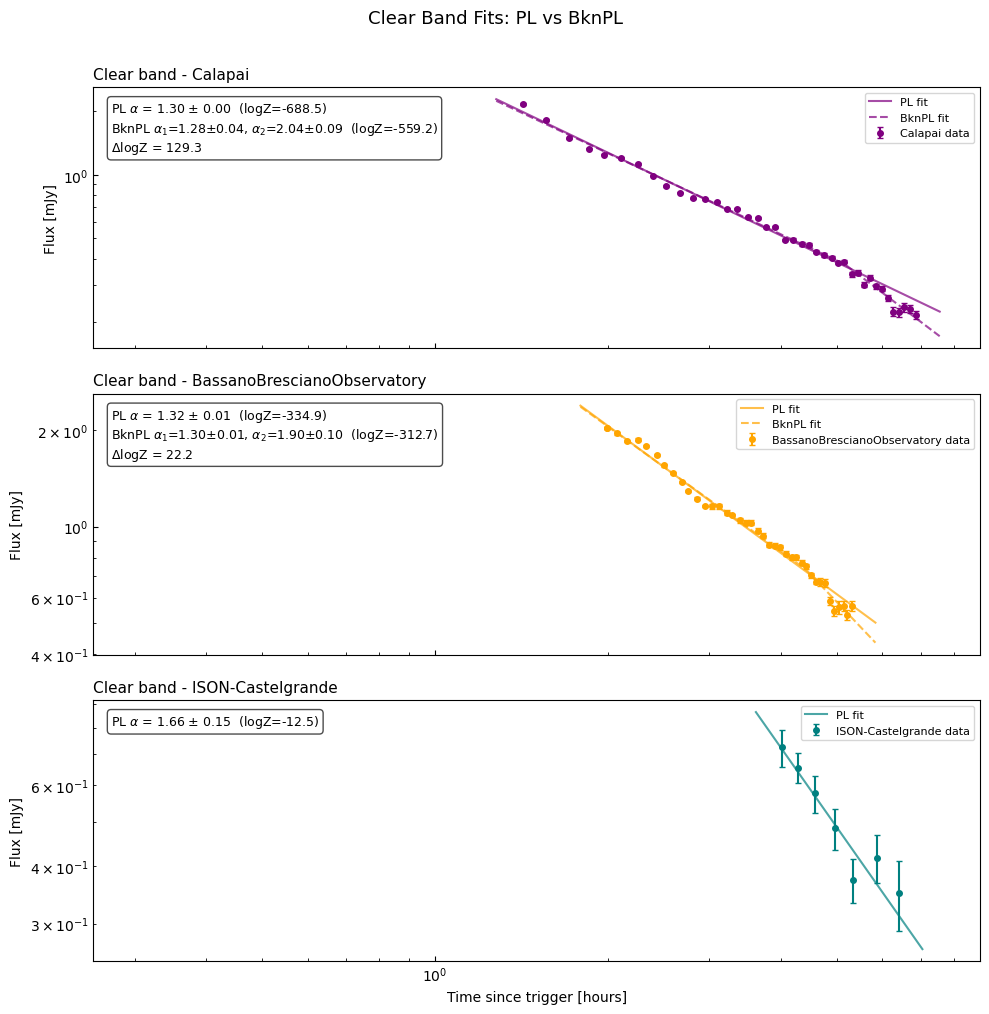

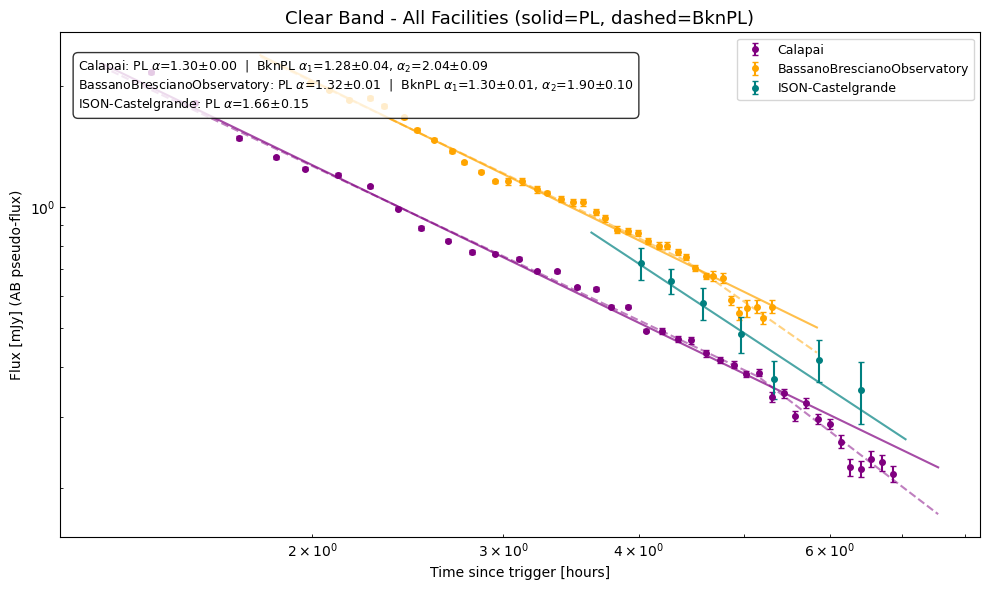

In [19]:
# Plot clear band results from saved pkl (PL + BknPL comparison)
import pickle
import numpy as np
import matplotlib.pyplot as plt
from grb.functions import power_law, broken_power_law

with open("clear_band_results.pkl", "rb") as f:
    clear_data = pickle.load(f)

facilities = ["Calapai", "BassanoBrescianoObservatory", "ISON-Castelgrande"]
bknpl_facilities = ["Calapai", "BassanoBrescianoObservatory"]
colors = {"Calapai": "purple", "BassanoBrescianoObservatory": "orange", "ISON-Castelgrande": "teal"}

# --- Per-facility plots: PL vs BknPL ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for ax, fac in zip(axes, facilities):
    d_pl = clear_data[f"clear_{fac}_PL"]
    x = np.array(d_pl["x_data"])
    y = np.array(d_pl["y_data"])
    yerr = np.array(d_pl["y_data_error"]) if d_pl["y_data_error"] is not None else None

    ax.errorbar(x, y, yerr=yerr, fmt="o", color=colors[fac], ms=4, capsize=2, label=f"{fac} data")

    # PL model
    t_model = np.geomspace(x.min() * 0.9, x.max() * 1.1, 300)
    y_pl = power_law(t_model, *d_pl["best_fit_params"])
    ax.plot(t_model, y_pl, color=colors[fac], lw=1.5, alpha=0.7, label="PL fit")

    # BknPL model (if available)
    bknpl_key = f"clear_{fac}_BknPL"
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        y_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
        ax.plot(t_model, y_bk, color=colors[fac], lw=1.5, ls="--", alpha=0.7, label="BknPL fit")

    # Annotations
    txt_lines = [fr"PL $\alpha$ = {d_pl['alpha_mean']:.2f} $\pm$ {d_pl['alpha_std']:.2f}  (logZ={d_pl['logz']:.1f})"]
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        means = d_bk["results"]["posterior"]["mean"]
        stds = d_bk["results"]["posterior"]["stdev"]
        txt_lines.append(fr"BknPL $\alpha_1$={means[2]:.2f}$\pm${stds[2]:.2f}, $\alpha_2$={means[3]:.2f}$\pm${stds[3]:.2f}  (logZ={d_bk['logz']:.1f})")
        txt_lines.append(fr"$\Delta$logZ = {d_bk['logz'] - d_pl['logz']:.1f}")
    ax.text(0.02, 0.95, "\n".join(txt_lines),
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
    ax.set_title(f"Clear band - {fac}", fontsize=11, loc="left")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Flux [mJy]")
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(which="both", direction="in")

axes[-1].set_xlabel("Time since trigger [hours]")
fig.suptitle("Clear Band Fits: PL vs BknPL", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("clear_band_fits.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Combined plot ---
fig, ax = plt.subplots(figsize=(10, 6))

for fac in facilities:
    d_pl = clear_data[f"clear_{fac}_PL"]
    x = np.array(d_pl["x_data"])
    y = np.array(d_pl["y_data"])
    yerr = np.array(d_pl["y_data_error"]) if d_pl["y_data_error"] is not None else None

    ax.errorbar(x, y, yerr=yerr, fmt="o", color=colors[fac], ms=4, capsize=2, label=fac)
    t_model = np.geomspace(x.min() * 0.9, x.max() * 1.1, 300)
    y_pl = power_law(t_model, *d_pl["best_fit_params"])
    ax.plot(t_model, y_pl, color=colors[fac], lw=1.5, alpha=0.7)

    bknpl_key = f"clear_{fac}_BknPL"
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        y_bk = broken_power_law(t_model, *d_bk["best_fit_params"])
        ax.plot(t_model, y_bk, color=colors[fac], lw=1.5, ls="--", alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time since trigger [hours]")
ax.set_ylabel("Flux [mJy] (AB pseudo-flux)")
ax.set_title("Clear Band - All Facilities (solid=PL, dashed=BknPL)", fontsize=13)

txt_lines = []
for fac in facilities:
    d_pl = clear_data[f"clear_{fac}_PL"]
    line = fr"{fac}: PL $\alpha$={d_pl['alpha_mean']:.2f}$\pm${d_pl['alpha_std']:.2f}"
    bknpl_key = f"clear_{fac}_BknPL"
    if bknpl_key in clear_data:
        d_bk = clear_data[bknpl_key]
        means = d_bk["results"]["posterior"]["mean"]
        stds = d_bk["results"]["posterior"]["stdev"]
        line += fr"  |  BknPL $\alpha_1$={means[2]:.2f}$\pm${stds[2]:.2f}, $\alpha_2$={means[3]:.2f}$\pm${stds[3]:.2f}"
    txt_lines.append(line)
txt = "\n".join(txt_lines)
ax.text(0.02, 0.95, txt, transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))

ax.legend(loc="upper right", fontsize=9)
ax.tick_params(which="both", direction="in")
plt.tight_layout()
plt.savefig("clear_band_combined.png", dpi=150, bbox_inches="tight")
plt.show()